## Importing Dataset and Describing it

In [1]:
import pandas as pd
df=pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Cleaning Data

In [6]:
df.isnull().sum()  #tells us about the missing values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## There are 2 ways to clean a Dataset



### Drop rows when missing is small

In [7]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])

### Fill Missing Values 

In [8]:
df['director']= df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')

In [9]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [10]:
df['date_added']

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8790, dtype: str

### Clean the text

In [11]:
df['date_added'] = df['date_added'].str.strip() #used for text 

In [12]:
df['date_added']=pd.to_datetime(df['date_added']) #changing date time

In [13]:
df['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8790, dtype: datetime64[us]

In [14]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Check for Duplicates

In [15]:
df.duplicated().sum()

np.int64(0)

### Rename Columns

In [16]:
df.rename(columns={"rating": "category"}, inplace=True)

### Visualizations

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   str           
 1   type          8790 non-null   str           
 2   title         8790 non-null   str           
 3   director      8790 non-null   str           
 4   cast          8790 non-null   str           
 5   country       8790 non-null   str           
 6   date_added    8790 non-null   datetime64[us]
 7   release_year  8790 non-null   int64         
 8   category      8790 non-null   str           
 9   duration      8790 non-null   str           
 10  listed_in     8790 non-null   str           
 11  description   8790 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 892.7 KB


In [18]:
import matplotlib.pyplot as plt

### Barcharts are used for cateogircal analysis

### Shows vs Movies

<Figure size 1000x500 with 0 Axes>

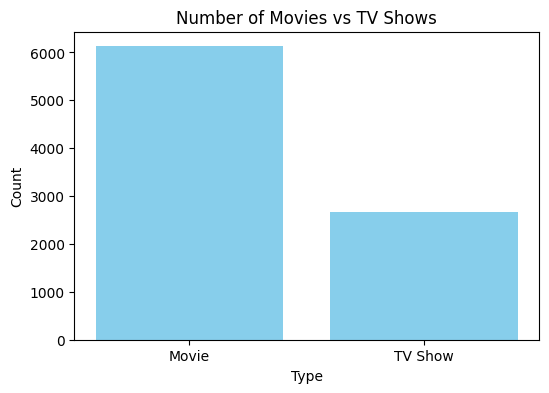

In [29]:
type_counts = df['type'].value_counts()
plt.figure(figsize=(10,5))
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color='skyblue')
plt.title('Number of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

##  Barchart of How much Content per Category

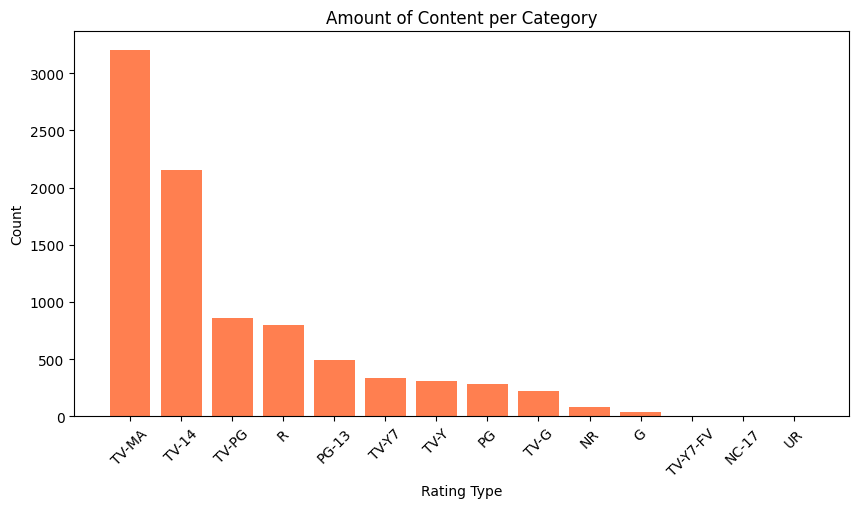

In [28]:
#Get conts for each  category
rating_counts=df['category'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(rating_counts.index, rating_counts.values, color='coral')
plt.title('Amount of Content per Category')
plt.xlabel('Rating Type')
plt.ylabel('Count')
plt.xticks(rotation=45) #prevent label overlapping
plt.show()

###  Barchart for Top 10 countires by number of shows

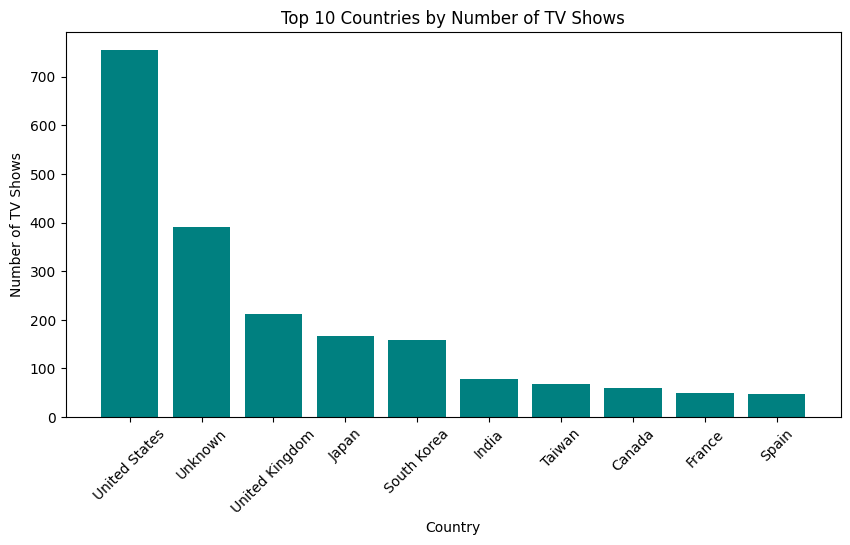

In [20]:
shows = df[df['type'] == 'TV Show']
top_countries = shows['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_countries.index, top_countries.values, color='teal')
plt.title('Top 10 Countries by Number of TV Shows')
plt.xlabel('Country')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=45)
plt.show()

### Barchart  of Top 10 Movies by Country

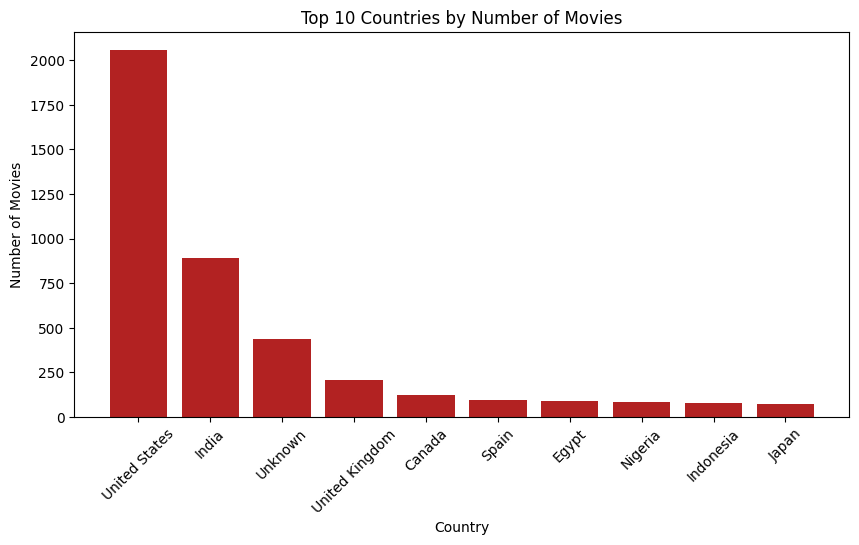

In [21]:
movies = df[df['type']=='Movie'] #Filters movies from the type and creates df of them

top_countries = movies['country'].value_counts().head(10)  

plt.figure(figsize=(10,5))
plt.bar(top_countries.index, top_countries.values, color='firebrick')  
plt.title('Top 10 Countries by Number of Movies')
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

### BArchart for Top 10 Directors

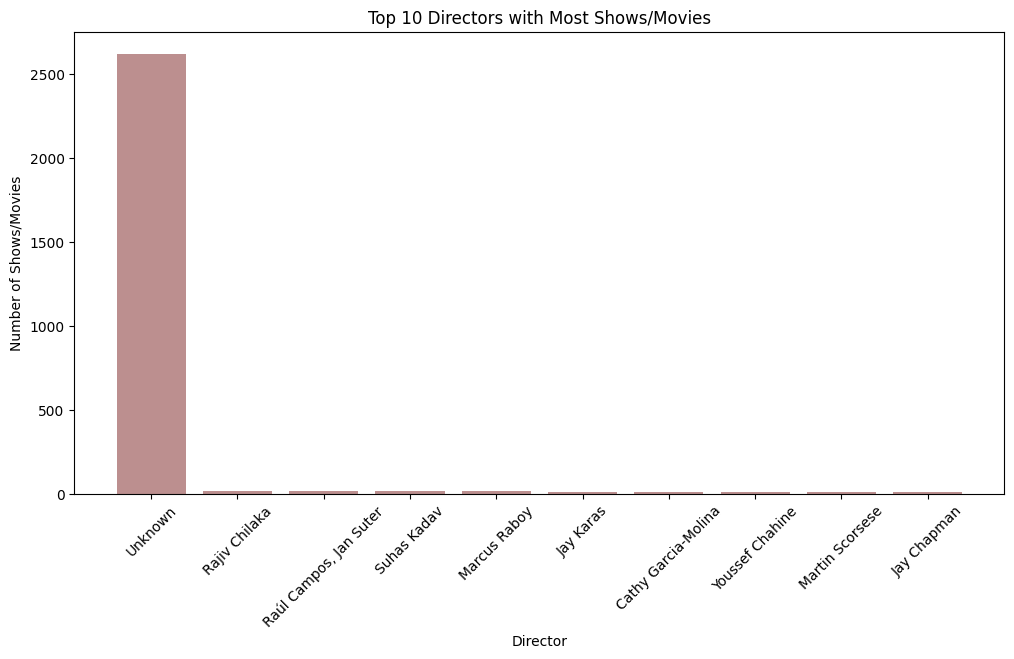

In [36]:
directors = df['director'].dropna()

top_directors = directors.value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(top_directors.index, top_directors.values, color='rosybrown')
plt.title('Top 10 Directors with Most Shows/Movies')
plt.xlabel('Director')
plt.ylabel('Number of Shows/Movies')
plt.xticks(rotation=45)
plt.show()

### Top Genres

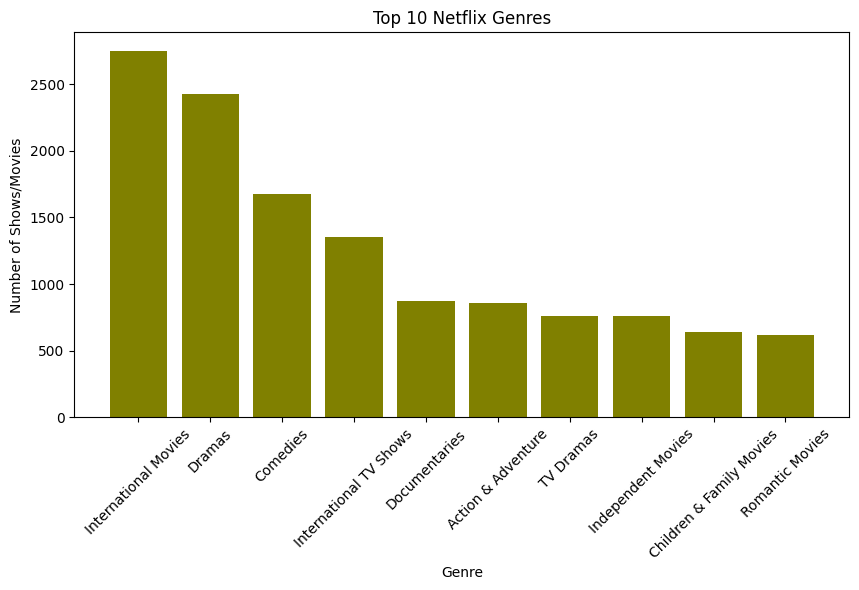

In [37]:
from collections import Counter

genres = df['listed_in'].str.split(', ').sum() #splits genres

top_genres = Counter(genres).most_common(10) #counts freq and takes top 10

# Plot
plt.figure(figsize=(10,5))
plt.bar([g[0] for g in top_genres], [g[1] for g in top_genres], color='olive')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Shows/Movies')
plt.xticks(rotation=45)
plt.show()

### Histograms are used for single numeric variable lets see numeric values from our dataset

### Distribution of Content Release Year

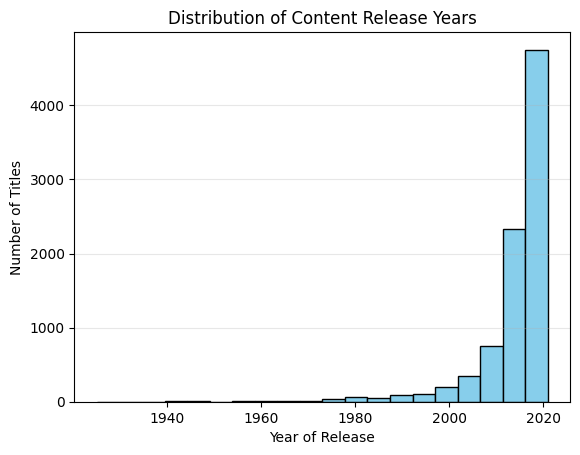

In [50]:
import matplotlib.pyplot as plt

plt.hist(df['release_year'], bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Content Release Years')
plt.xlabel('Year of Release')
plt.ylabel('Number of Titles')
plt.grid(axis='y', alpha=0.3)
plt.show()

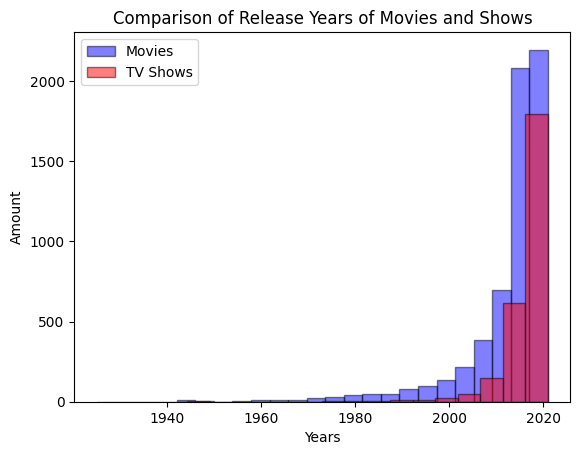

In [53]:
movies = df[df['type'] == 'Movie']['release_year']
tv_shows = df[df['type'] == 'TV Show']['release_year']

plt.hist(movies, bins=20, alpha=0.5, label='Movies', color='blue', edgecolor='black')
plt.hist(tv_shows, bins=20, alpha=0.5, label='TV Shows', color='red', edgecolor='black')

plt.title('Comparison of Release Years of Movies and Shows')
plt.xlabel('Years')
plt.ylabel('Amount')
plt.legend()
plt.show()

### Scatter plots are used to find relationships between numerical values

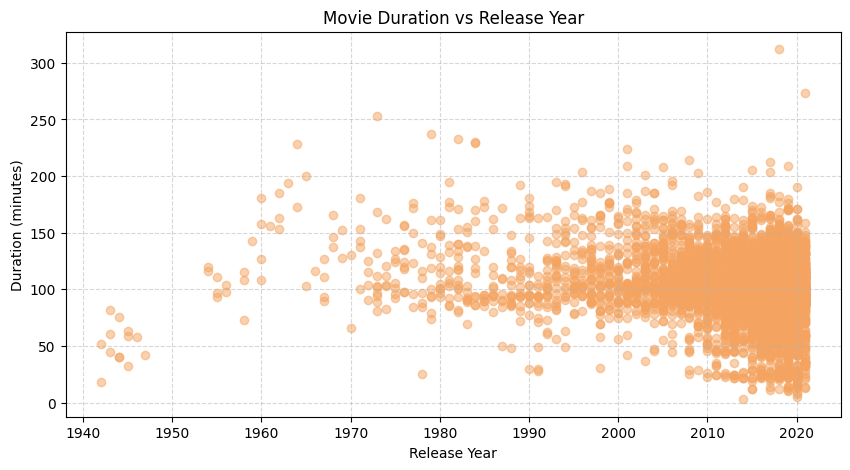

In [57]:
import matplotlib.pyplot as plt

movies = df[df['type'] == 'Movie'].copy()

movies['duration_min'] = movies['duration'].str.replace(' min','').astype(int)

plt.figure(figsize=(10,5))
plt.scatter(movies['release_year'], movies['duration_min'], color='sandybrown', alpha=0.5)
plt.title('Movie Duration vs Release Year')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()